# Descriptive Statistics Assigment for Data Visualization Course

In [1]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
%matplotlib inline

import math

In [2]:
df = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vS5YkI613Xtm0-uSA6NozEkDAWm17X7G-iCh_tVPrEv48RNmwgqkRpdwFcJntWRcTQOoMv1y2T1bBwC/pub?gid=1701574632&single=true&output=csv')
print(f'Dữ liệu gồm: {df.shape[0]:,} dòng')
display(df.head(5))
df.info()

Dữ liệu gồm: 82,137 dòng


,Thời gian tạo đơn,Mã đơn hàng,Mã khách hàng,Tên khách hàng,Mã PKKH,Mô tả Phân Khúc Khách hàng,Mã nhóm hàng,Tên nhóm hàng,Mã mặt hàng,Tên mặt hàng,SL,Đơn giá,Thành tiền
0,2022-01-01 08:01:09,ORD0000001,CUZ00001,Lê Vũ Tâm,A1,"Nhân viên văn phòng, chủ doanh nghiệp (36-45 t...",BOT,Bột,BOT01,Bột cần tây,1,40000,40000
1,2022-01-01 08:01:09,ORD0000001,CUZ00001,Lê Vũ Tâm,A1,"Nhân viên văn phòng, chủ doanh nghiệp (36-45 t...",SET,Set trà,SET03,Set 10 gói trà hoa cúc trắng,1,150000,150000
2,2022-01-01 08:01:09,ORD0000001,CUZ00001,Lê Vũ Tâm,A1,"Nhân viên văn phòng, chủ doanh nghiệp (36-45 t...",THO,Trà hoa,THO05,Trà hoa Atiso,1,50000,50000
3,2022-01-01 08:01:09,ORD0000001,CUZ00001,Lê Vũ Tâm,A1,"Nhân viên văn phòng, chủ doanh nghiệp (36-45 t...",TTC,"Trà củ, quả sấy",TTC01,Trà gừng,1,30000,30000
4,2022-01-01 08:18:12,ORD0000002,CUZ00002,Phạm Công Bình,A2,"Nhân viên văn phòng, Freelancer ở Miền Bắc (25...",BOT,Bột,BOT01,Bột cần tây,1,40000,40000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82137 entries, 0 to 82136
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Thời gian tạo đơn           82137 non-null  object
 1   Mã đơn hàng                 82137 non-null  object
 2   Mã khách hàng               82137 non-null  object
 3   Tên khách hàng              79619 non-null  object
 4   Mã PKKH                     82137 non-null  object
 5   Mô tả Phân Khúc Khách hàng  82137 non-null  object
 6   Mã nhóm hàng                82137 non-null  object
 7   Tên nhóm hàng               82137 non-null  object
 8   Mã mặt hàng                 82137 non-null  object
 9   Tên mặt hàng                82137 non-null  object
 10  SL                          82137 non-null  int64 
 11  Đơn giá                     82137 non-null  int64 
 12  Thành tiền                  82137 non-null  int64 
dtypes: int64(3), object(10)
memory usage: 8.1+ MB


In [3]:
# Tạo cột mới kết hợp mã nhóm hàng và tên nhóm hàng
df['Mã và Tên nhóm hàng'] = df['Mã nhóm hàng'] + ' - ' + df['Tên nhóm hàng']

# Tạo cột mới kết hợp mã mặt hàng và tên mặt hàng
df['Mã và Tên mặt hàng'] = df['Mã mặt hàng'] + ' - ' + df['Tên mặt hàng']

# Hiển thị 5 dòng đầu tiên để kiểm tra
df[['Mã và Tên nhóm hàng', 'Mã và Tên mặt hàng']].head()

,Mã và Tên nhóm hàng,Mã và Tên mặt hàng
0,BOT - Bột,BOT01 - Bột cần tây
1,SET - Set trà,SET03 - Set 10 gói trà hoa cúc trắng
2,THO - Trà hoa,THO05 - Trà hoa Atiso
3,"TTC - Trà củ, quả sấy",TTC01 - Trà gừng
4,BOT - Bột,BOT01 - Bột cần tây


In [4]:
df

,Thời gian tạo đơn,Mã đơn hàng,Mã khách hàng,Tên khách hàng,Mã PKKH,Mô tả Phân Khúc Khách hàng,Mã nhóm hàng,Tên nhóm hàng,Mã mặt hàng,Tên mặt hàng,SL,Đơn giá,Thành tiền,Mã và Tên nhóm hàng,Mã và Tên mặt hàng
0,2022-01-01 08:01:09,ORD0000001,CUZ00001,Lê Vũ Tâm,A1,"Nhân viên văn phòng, chủ doanh nghiệp (36-45 t...",BOT,Bột,BOT01,Bột cần tây,1,40000,40000,BOT - Bột,BOT01 - Bột cần tây
1,2022-01-01 08:01:09,ORD0000001,CUZ00001,Lê Vũ Tâm,A1,"Nhân viên văn phòng, chủ doanh nghiệp (36-45 t...",SET,Set trà,SET03,Set 10 gói trà hoa cúc trắng,1,150000,150000,SET - Set trà,SET03 - Set 10 gói trà hoa cúc trắng
2,2022-01-01 08:01:09,ORD0000001,CUZ00001,Lê Vũ Tâm,A1,"Nhân viên văn phòng, chủ doanh nghiệp (36-45 t...",THO,Trà hoa,THO05,Trà hoa Atiso,1,50000,50000,THO - Trà hoa,THO05 - Trà hoa Atiso
3,2022-01-01 08:01:09,ORD0000001,CUZ00001,Lê Vũ Tâm,A1,"Nhân viên văn phòng, chủ doanh nghiệp (36-45 t...",TTC,"Trà củ, quả sấy",TTC01,Trà gừng,1,30000,30000,"TTC - Trà củ, quả sấy",TTC01 - Trà gừng
4,2022-01-01 08:18:12,ORD0000002,CUZ00002,Phạm Công Bình,A2,"Nhân viên văn phòng, Freelancer ở Miền Bắc (25...",BOT,Bột,BOT01,Bột cần tây,1,40000,40000,BOT - Bột,BOT01 - Bột cần tây
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82132,2022-12-31 23:35:13,ORD0031436,CUZ05008,Phùng Quốc Anh,B1,Người làm kinh doanh hoặc văn phòng (45+ tuổi)...,TMX,Trà mix,TMX03,Trà gạo lứt 8 vị,1,18000,18000,TMX - Trà mix,TMX03 - Trà gạo lứt 8 vị
82133,2022-12-31 23:41:46,ORD0031437,CUZ03356,Đoàn Thành Thái,A1,"Nhân viên văn phòng, chủ doanh nghiệp (36-45 t...",BOT,Bột,BOT01,Bột cần tây,1,40000,40000,BOT - Bột,BOT01 - Bột cần tây
82134,2022-12-31 23:41:46,ORD0031437,CUZ03356,Đoàn Thành Thái,A1,"Nhân viên văn phòng, chủ doanh nghiệp (36-45 t...",TMX,Trà mix,TMX02,Trà cam sả quế,1,38000,38000,TMX - Trà mix,TMX02 - Trà cam sả quế
82135,2022-12-31 23:48:48,ORD0031438,CUZ08388,Nguyễn Hoàng Khiêm,A1,"Nhân viên văn phòng, chủ doanh nghiệp (36-45 t...",BOT,Bột,BOT01,Bột cần tây,1,40000,40000,BOT - Bột,BOT01 - Bột cần tây


### 1. Năm qua, mặt hàng nào bán chạy nhất? mặt hàng nào bán kém nhất?. Vẽ biểu đồ trực quan và đưa ra nhận định của bản thân lý giải nguyên do của kết quả.
<i>*Note: Trả lời thành văn bản trong đó có thông tin Mã mặt hàng, Tên mặt hàng, Số lượng bán, Doanh số bán.</i>

Mặt hàng bán chạy nhất là Bột cần tây (mã BOT01) với doanh thu là 626,000,000 VND (SL: 15,650 SKU).
Mặt hàng bán kém nhất là Set 10 gói trà gạo lứt 8 vị (mã SET06) với doanh thu là 31,850,000 VND (SL: 910 SKU).


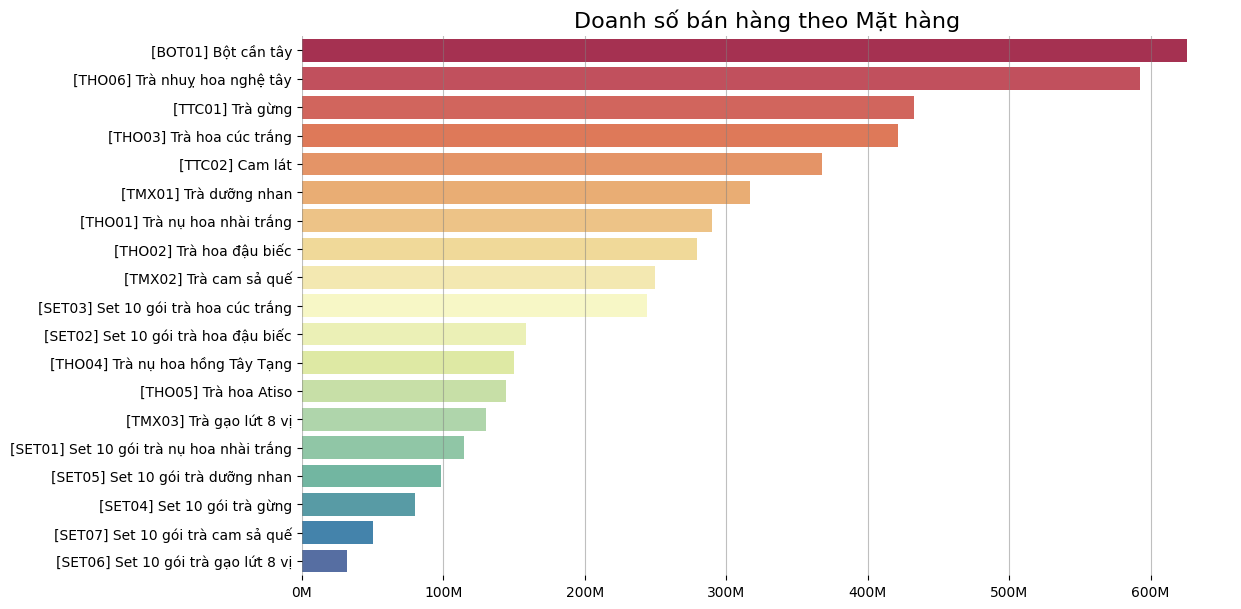

In [10]:
# Import matplotlib.ticker as mtick
import matplotlib.ticker as mtick

# Tạo cột Doanh thu
df["DoanhThu"] = df["SL"] * df["Đơn giá"]
# Gom nhóm theo Mã mặt hàng và Tên mặt hàng
grouped = df.groupby(["Mã mặt hàng", "Tên mặt hàng"], as_index=False).agg({
    "SL": "sum",
    "DoanhThu": "sum"
})
# Thêm cột hiển thị với format [Mã] Tên
grouped["Hiển thị"] = "[" + grouped["Mã mặt hàng"].astype(str) + "] " + grouped["Tên mặt hàng"]
# Sắp xếp theo Doanh thu giảm dần
grouped = grouped.sort_values(by="DoanhThu", ascending=False)
# Lấy mặt hàng bán chạy nhất và kém nhất
top_item = grouped.iloc[0]
bottom_item = grouped.iloc[-1]
# In thông tin như trong ảnh mẫu
print(f"Mặt hàng bán chạy nhất là {top_item['Tên mặt hàng']} (mã {top_item['Mã mặt hàng']}) "
      f"với doanh thu là {top_item['DoanhThu']:,} VND (SL: {top_item['SL']:,} SKU).")
print(f"Mặt hàng bán kém nhất là {bottom_item['Tên mặt hàng']} (mã {bottom_item['Mã mặt hàng']}) "
      f"với doanh thu là {bottom_item['DoanhThu']:,} VND (SL: {bottom_item['SL']:,} SKU).")
# Vẽ biểu đồ
plt.figure(figsize=(12,7))
ax = sns.barplot(
    data=grouped,
    x="DoanhThu",
    y="Hiển thị",
    hue="Hiển thị",
    dodge=False,
    palette="Spectral",
    legend=False
)
plt.title("Doanh số bán hàng theo Mặt hàng", fontsize=16)
plt.xlabel("")
plt.ylabel("")
ax.xaxis.grid(True, linestyle="-", linewidth=0.8, color="gray", alpha=0.5) # thêm kẻ đậm
# Format trục X sang triệu VND
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x/1e6)}M'))
# ❌ Xóa khung viền (4 cạnh)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()

Mặt hàng bán chạy nhất là Bột cần tây với doanh thu 626,000,000 VNĐ
Mặt hàng bán tệ nhất là Set 10 gói trà gạo lứt 8 vị với doanh thu 31,850,000 VNĐ


### 2. Năm qua, nhóm hàng nào bán chạy nhất? nhóm hàng nào bán kém nhất?. Vẽ biểu đồ trực quan và đưa ra nhận định của bản thân lý giải nguyên do của kết quả.
<i>*Note: Trả lời thành văn bản trong đó có thông tin Mã nhóm hàng, Tên nhóm hàng, Số lượng bán, Doanh số bán.</i>

Nhóm hàng bán chạy nhất là THO - Trà hoa với doanh thu là 1,878 triệu VNĐ (SL: 6 SKU).
Nhóm hàng bán kém nhất là BOT - Bột với doanh thu là 626 triệu VNĐ (SL: 1 SKU).


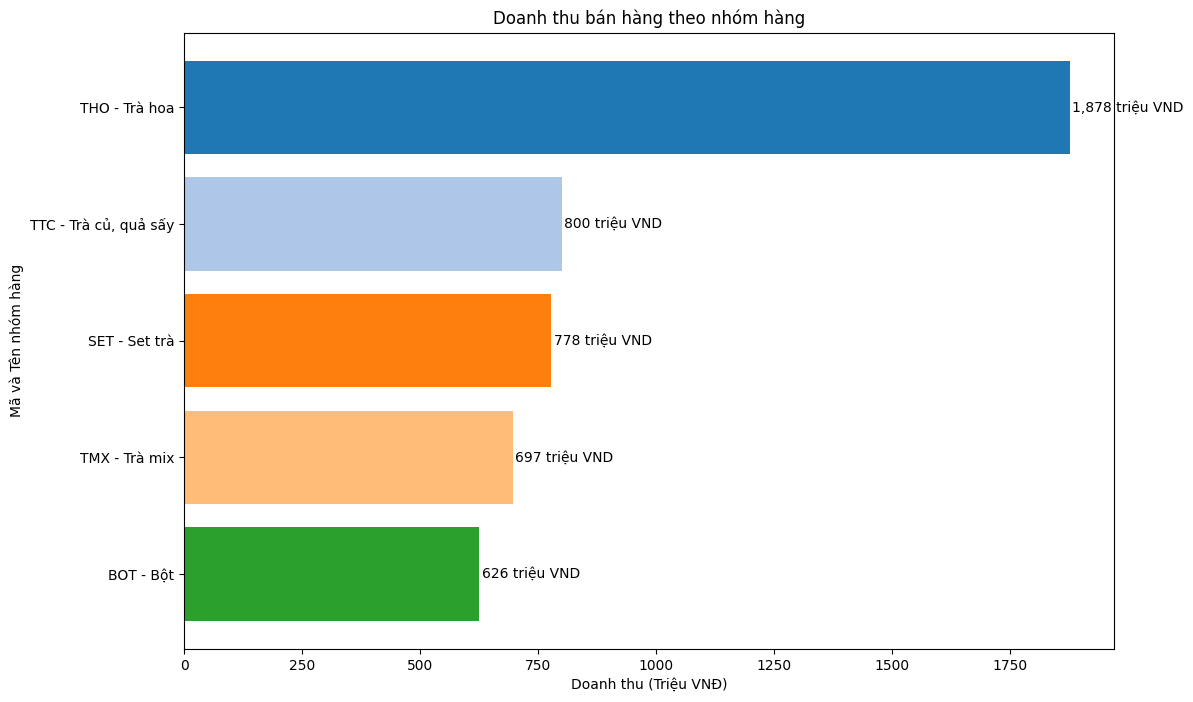

In [12]:
# Tính tổng doanh thu theo nhóm hàng và chuyển đổi sang đơn vị triệu VNĐ
# Lấy nhóm hàng bán chạy nhất và bán kém nhất dựa trên doanh thu
# Tính tổng doanh thu theo nhóm hàng và chuyển đổi sang đơn vị triệu VNĐ
group_summary = df.groupby('Mã và Tên nhóm hàng')['Thành tiền'].sum().sort_values(ascending=False) / 1e6

# Lấy nhóm hàng bán chạy nhất và bán kém nhất dựa trên doanh thu
best_group = group_summary.idxmax()
best_group_revenue = group_summary.max()
best_group_sku = df[df['Mã và Tên nhóm hàng'] == best_group]['Mã mặt hàng'].nunique()

worst_group = group_summary.idxmin()
worst_group_revenue = group_summary.min()
worst_group_sku = df[df['Mã và Tên nhóm hàng'] == worst_group]['Mã mặt hàng'].nunique()

# In kết quả
print(f"Nhóm hàng bán chạy nhất là {best_group} với doanh thu là {best_group_revenue:,.0f} triệu VNĐ (SL: {best_group_sku} SKU).")
print(f"Nhóm hàng bán kém nhất là {worst_group} với doanh thu là {worst_group_revenue:,.0f} triệu VNĐ (SL: {worst_group_sku} SKU).")

# Vẽ biểu đồ
plt.figure(figsize=(12, 8))
bars = plt.barh(group_summary.index, group_summary.values, color=colors[:len(group_summary)])

# Thêm nhãn doanh thu trên mỗi cột
for bar in bars:
    plt.text(
        bar.get_width() + 5,  # Vị trí x của nhãn
        bar.get_y() + bar.get_height() / 2,  # Vị trí y của nhãn
        f'{bar.get_width():,.0f} triệu VND',  # Giá trị doanh thu
        va='center'
    )

plt.xlabel("Doanh thu (Triệu VNĐ)")
plt.ylabel("Mã và Tên nhóm hàng")
plt.title("Doanh thu bán hàng theo nhóm hàng")
plt.gca().invert_yaxis()  # Để nhóm hàng có doanh thu cao nhất nằm trên cùng
plt.show()

### 3. Năm qua, tháng nào bán chạy nhất? tháng nào bán kém nhất?. Vẽ biểu đồ trực quan và đưa ra nhận định của bản thân lý giải nguyên do của kết quả.
<i>*Note: Trả lời thành văn bản trong đó có thông tin Tháng, Số lượng bán, Doanh số bán.</i>

Tháng bán chạy nhất là tháng 12 với doanh số 750 triệu VNĐ và số lượng bán 14496.
Tháng bán kém nhất là tháng 4 với doanh số 196 triệu VNĐ và số lượng bán 3621.


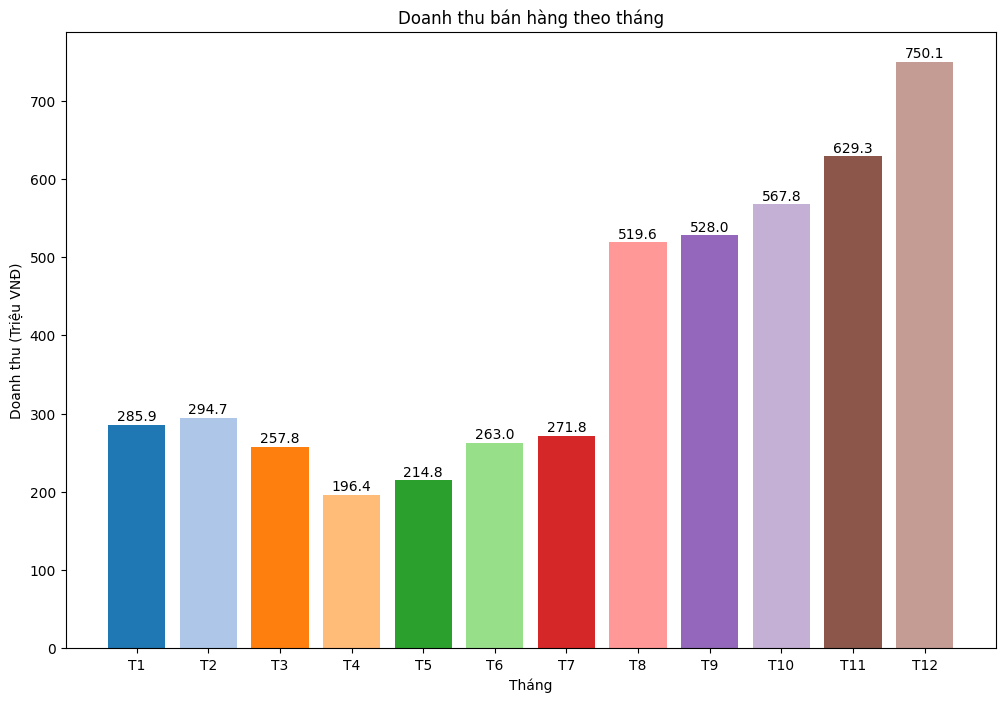

In [13]:
# Chuyển đổi cột 'Thời gian tạo đơn' sang kiểu datetime và tạo cột 'Tháng'
df['Thời gian tạo đơn'] = pd.to_datetime(df['Thời gian tạo đơn'])
df['Tháng'] = df['Thời gian tạo đơn'].dt.month

# Tính tổng doanh thu và số lượng bán theo tháng
monthly_summary = df.groupby('Tháng').agg({'Thành tiền': 'sum', 'SL': 'sum'}).reset_index()
monthly_summary['Doanh_so_trieu'] = monthly_summary['Thành tiền'] / 1e6

# Xác định tháng bán chạy nhất và bán kém nhất
best_month = monthly_summary.loc[monthly_summary['Thành tiền'].idxmax()]
worst_month = monthly_summary.loc[monthly_summary['Thành tiền'].idxmin()]

# In kết quả
print(
    f"Tháng bán chạy nhất là tháng {int(best_month['Tháng'])} "
    f"với doanh số {round(best_month['Doanh_so_trieu']):.0f} triệu VNĐ "
    f"và số lượng bán {int(best_month['SL'])}."
)

print(
    f"Tháng bán kém nhất là tháng {int(worst_month['Tháng'])} "
    f"với doanh số {round(worst_month['Doanh_so_trieu']):.0f} triệu VNĐ "
    f"và số lượng bán {int(worst_month['SL'])}."
)

#----------------------------------------------
plt.figure(figsize=(12, 8))
bars = plt.bar(
    monthly_summary['Tháng'], 
    monthly_summary['Doanh_so_trieu'], 
    color=colors[:len(monthly_summary)]
)

# Thêm nhãn doanh thu trên mỗi cột
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # Vị trí x của nhãn
        bar.get_height() + 5,  # Vị trí y của nhãn
        f'{bar.get_height():,.1f}',  # Giá trị doanh thu
        ha='center'
    )

plt.xlabel("Tháng")
plt.ylabel("Doanh thu (Triệu VNĐ)")
plt.title("Doanh thu bán hàng theo tháng")

# Chuyển tháng thành T1, T2, T3...
labels = [f"T{t}" for t in monthly_summary['Tháng']]
plt.xticks(monthly_summary['Tháng'], labels)

plt.show()



### 4. Năm qua, ngày nào trong tuần thường bán chạy nhất? ngày nào trong tuần thường bán kém nhất?. Vẽ biểu đồ trực quan và đưa ra nhận định của bản thân lý giải nguyên do của kết quả.
<i>*Note: Trả lời thành văn bản trong đó có thông tin Ngày trong tuần, Số lượng bán, Doanh số bán.</i>

Ngày trong tuần bán chạy nhất là Thứ 7 với doanh thu TB là 14,493,547 VNĐ (Số lượng SKU bán ra TB: 280).
Ngày trong tuần bán kém nhất là Thứ 3 với doanh thu TB là 11,891,769 VNĐ (Số lượng SKU bán ra TB: 229).


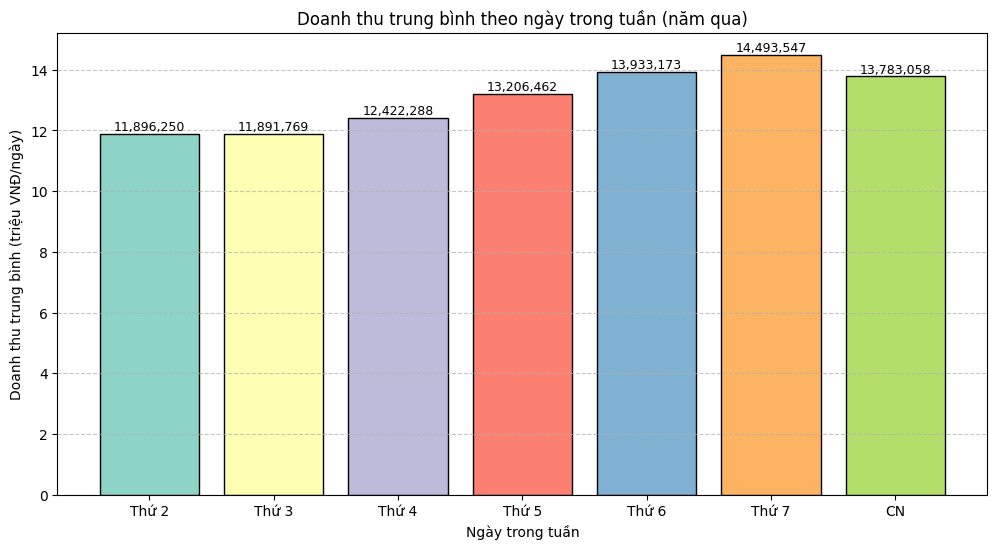

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
# Đảm bảo datetime
df['Thời gian tạo đơn'] = pd.to_datetime(df['Thời gian tạo đơn'])

# Doanh thu & SL theo ngày
daily_stats = df.groupby(df['Thời gian tạo đơn'].dt.date).agg({
    'Thành tiền':'sum',
    'SL':'sum'
}).reset_index()
daily_stats['Thời gian tạo đơn'] = pd.to_datetime(daily_stats['Thời gian tạo đơn'])
daily_stats['Thứ'] = daily_stats['Thời gian tạo đơn'].dt.dayofweek.map({
    0:"Thứ 2",1:"Thứ 3",2:"Thứ 4",3:"Thứ 5",4:"Thứ 6",5:"Thứ 7",6:"CN"
})

# Trung bình theo thứ
avg_stats = daily_stats.groupby('Thứ').agg({
    'Thành tiền':'mean',
    'SL':'mean'
}).reset_index()

# Sắp xếp đúng thứ tự
thu_order = ["Thứ 2","Thứ 3","Thứ 4","Thứ 5","Thứ 6","Thứ 7","CN"]
avg_stats['Thứ'] = pd.Categorical(avg_stats['Thứ'], categories=thu_order, ordered=True)
avg_stats = avg_stats.sort_values('Thứ')

# Ngày tốt nhất & kém nhất
best = avg_stats.loc[avg_stats['Thành tiền'].idxmax()]
worst = avg_stats.loc[avg_stats['Thành tiền'].idxmin()]

# In kết quả theo format yêu cầu
print(
    f"Ngày trong tuần bán chạy nhất là {best['Thứ']} "
    f"với doanh thu TB là {best['Thành tiền']:,.0f} VNĐ "
    f"(Số lượng SKU bán ra TB: {best['SL']:,.0f})."
)

print(
    f"Ngày trong tuần bán kém nhất là {worst['Thứ']} "
    f"với doanh thu TB là {worst['Thành tiền']:,.0f} VNĐ "
    f"(Số lượng SKU bán ra TB: {worst['SL']:,.0f})."
)
# ... (đoạn tính avg_sales giữ nguyên như trước)

# Vẽ biểu đồ với nhiều màu
plt.figure(figsize=(12,6))
colors = plt.cm.Set3(range(len(avg_stats)))  # chọn bảng màu

bars = plt.bar(
    avg_stats['Thứ'], 
    avg_stats['Thành tiền']/1e6, 
    color=colors, edgecolor="black"
)

# Hiển thị số liệu chính xác trên mỗi cột
for bar, value in zip(bars, avg_stats['Thành tiền']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f"{value:,.0f}",   # số có dấu phẩy phân tách nghìn
        ha='center', fontsize=9
    )

plt.xlabel("Ngày trong tuần")
plt.ylabel("Doanh thu trung bình (triệu VNĐ/ngày)")
plt.title("Doanh thu trung bình theo ngày trong tuần (năm qua)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


### 5. Năm qua, ngày nào trong tháng thường bán chạy nhất? ngày nào trong tháng thường bán kém nhất?. Vẽ biểu đồ trực quan và đưa ra nhận định của bản thân lý giải nguyên do của kết quả.
<i>*Note: Trả lời thành văn bản trong đó có thông tin Ngày trong tháng, Số lượng bán, Doanh số bán.</i>

Ngày trong tháng bán chạy nhất là Ngày 17 với doanh thu TB là 14,263,333 VND (Số lượng SKU bán ra TB: 272).
Ngày trong tháng bán kém nhất là Ngày 31 với doanh thu TB là 11,655,571 VND (Số lượng SKU bán ra TB: 220).


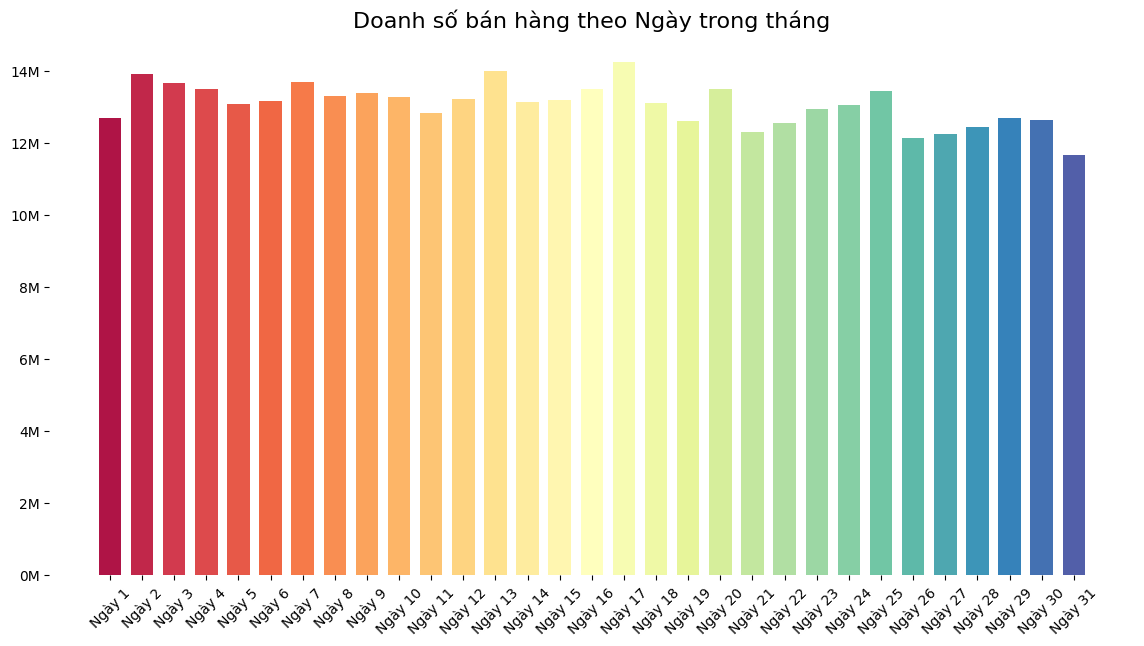

In [16]:


# --- Ép kiểu ngày ---
df["Ngày"] = pd.to_datetime(df["Thời gian tạo đơn"], format="%Y-%m-%d %H:%M:%S")

# --- B1: Tổng doanh thu & SKU theo từng ngày ---
daily = df.groupby(df["Ngày"].dt.date).agg(
    TongDoanhThu=("Thành tiền","sum"),
    TongSKU=("SL","sum")
).reset_index()

# --- B2: Lấy ngày trong tháng (1 -> 31) ---
daily["Ngày_trong_tháng"] = pd.to_datetime(daily["Ngày"]).dt.day

# --- B3: Doanh thu TB + SKU TB theo ngày trong tháng ---
grouped_day = daily.groupby("Ngày_trong_tháng").agg(
    DoanhThuTB=("TongDoanhThu","mean"),
    SKU_TB=("TongSKU","mean")
).reset_index().sort_values("Ngày_trong_tháng")

# --- B4: Tìm ngày max / min ---
top_day = grouped_day.loc[grouped_day["DoanhThuTB"].idxmax()]
bottom_day = grouped_day.loc[grouped_day["DoanhThuTB"].idxmin()]

print(f"Ngày trong tháng bán chạy nhất là Ngày {int(top_day['Ngày_trong_tháng'])} "
      f"với doanh thu TB là {top_day['DoanhThuTB']:,.0f} VND "
      f"(Số lượng SKU bán ra TB: {int(round(top_day['SKU_TB'])):,}).")

print(f"Ngày trong tháng bán kém nhất là Ngày {int(bottom_day['Ngày_trong_tháng'])} "
      f"với doanh thu TB là {bottom_day['DoanhThuTB']:,.0f} VND "
      f"(Số lượng SKU bán ra TB: {int(round(bottom_day['SKU_TB'])):,}).")

# --- B5: Vẽ biểu đồ ---
plt.figure(figsize=(14,7))
x = range(len(grouped_day))
colors = sns.color_palette("Spectral", len(grouped_day))

bars = plt.bar(x, grouped_day["DoanhThuTB"], width=0.7, color=colors)

plt.xticks(x, ["Ngày " + str(d) for d in grouped_day["Ngày_trong_tháng"]], rotation=45)
plt.title("Doanh số bán hàng theo Ngày trong tháng", fontsize=16)
plt.xlabel("")


# Format trục Y sang triệu VND
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y/1e6:.0f}M"))

# ❌ Tắt grid
plt.grid(False)

# ❌ Xóa toàn bộ spines (khung viền 4 cạnh)
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.show()


### 6. Năm qua, khung giờ nào thường bán chạy nhất? khung giờ nào thường bán kém nhất?. Vẽ biểu đồ trực quan và đưa ra nhận định của bản thân lý giải nguyên do của kết quả.
<i>*Note: Trả lời thành văn bản trong đó có thông tin Khung giờ, Số lượng bán, Doanh số bán.</i>

Khung giờ bán chạy nhất là 18:00-18:59 với doanh thu TB là 895,953 VND (Số lượng SKU bán ra TB: 17).
Khung giờ bán kém nhất là 09:00-09:59 với doanh thu TB là 746,272 VND (Số lượng SKU bán ra TB: 14).


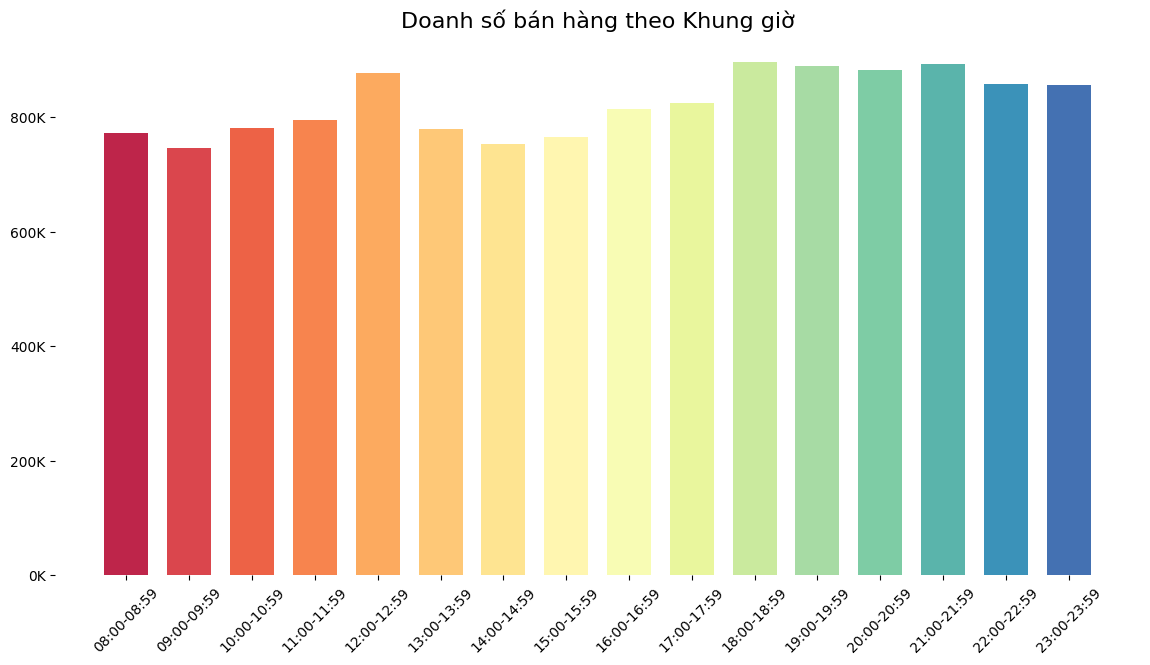

In [17]:

# --- Ép kiểu ngày giờ ---
df["Ngày"] = pd.to_datetime(df["Thời gian tạo đơn"], format="%Y-%m-%d %H:%M:%S")
df["Giờ"] = df["Ngày"].dt.hour

# --- B1: Tạo cột khung giờ dạng 08:00-08:59 ---
df["Khung_gio"] = df["Giờ"].astype(str).str.zfill(2) + ":00-" + df["Giờ"].astype(str).str.zfill(2) + ":59"

# --- B2: Tổng doanh thu & SKU theo từng ngày + giờ ---
daily_hour = df.groupby([df["Ngày"].dt.date, "Khung_gio"]).agg(
    TongDoanhThu=("Thành tiền","sum"),
    TongSKU=("SL","sum")
).reset_index()

# --- B3: Tính trung bình theo khung giờ (chuẩn AVERAGEX) ---
grouped_hour = daily_hour.groupby("Khung_gio").agg(
    DoanhThuTB=("TongDoanhThu","mean"),
    SKU_TB=("TongSKU","mean")
).reset_index()

# --- Sắp xếp khung giờ theo thứ tự thời gian ---
grouped_hour["Giờ_int"] = grouped_hour["Khung_gio"].str[:2].astype(int)
grouped_hour = grouped_hour.sort_values("Giờ_int")

# --- B4: Tìm khung giờ max / min ---
top_slot = grouped_hour.loc[grouped_hour["DoanhThuTB"].idxmax()]
bottom_slot = grouped_hour.loc[grouped_hour["DoanhThuTB"].idxmin()]

print(f"Khung giờ bán chạy nhất là {top_slot['Khung_gio']} "
      f"với doanh thu TB là {top_slot['DoanhThuTB']:,.0f} VND "
      f"(Số lượng SKU bán ra TB: {int(round(top_slot['SKU_TB'])):,}).")

print(f"Khung giờ bán kém nhất là {bottom_slot['Khung_gio']} "
      f"với doanh thu TB là {bottom_slot['DoanhThuTB']:,.0f} VND "
      f"(Số lượng SKU bán ra TB: {int(round(bottom_slot['SKU_TB'])):,}).")

plt.figure(figsize=(14,7))
x = range(len(grouped_hour))
colors = sns.color_palette("Spectral", len(grouped_hour))

# --- Vẽ dữ liệu gốc (không chia 1e6) ---
bars = plt.bar(x, grouped_hour["DoanhThuTB"], width=0.7, color=colors)

plt.xticks(x, grouped_hour["Khung_gio"], rotation=45)
plt.title("Doanh số bán hàng theo Khung giờ", fontsize=16)
plt.xlabel("")

# --- Format trục Y: 800K, 900K, 1M ---
def human_format(y, _):
    if y >= 1e6:
        return f"{y/1e6:.0f}M"
    else:
        return f"{y/1e3:.0f}K"

plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(human_format))

# Grid ngang nhẹ
plt.grid(axis="y", linestyle="-", linewidth=0.8, color="gray", alpha=0.5)
# ❌ Tắt grid
plt.grid(False)

# ❌ Xóa toàn bộ spines (khung viền 4 cạnh)
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.show()



### 7. Năm qua, nhóm hàng nào thường dễ bán nhất (có xác suất bán trên mỗi đơn hàng cao nhất)? nhóm hàng nào khó bán nhất (có xác suất bán trên mỗi đơn hàng thấp nhất)?. Vẽ biểu đồ trực quan (tất cả các nhóm hàng vào cùng figure) và đưa ra nhận định của bản thân lý giải nguyên do của kết quả.
<i>*Note: Trả lời thành văn bản trong đó có thông tin Mã nhóm hàng, Tên nhóm hàng, Xác suất bán trên đơn hàng.</i>

Nhóm hàng bán dễ nhất là [TMX] Trà mix với xác suất bán là 54.53%.
Nhóm hàng bán khó nhất là [SET] Set trà với xác suất bán là 23.86%.


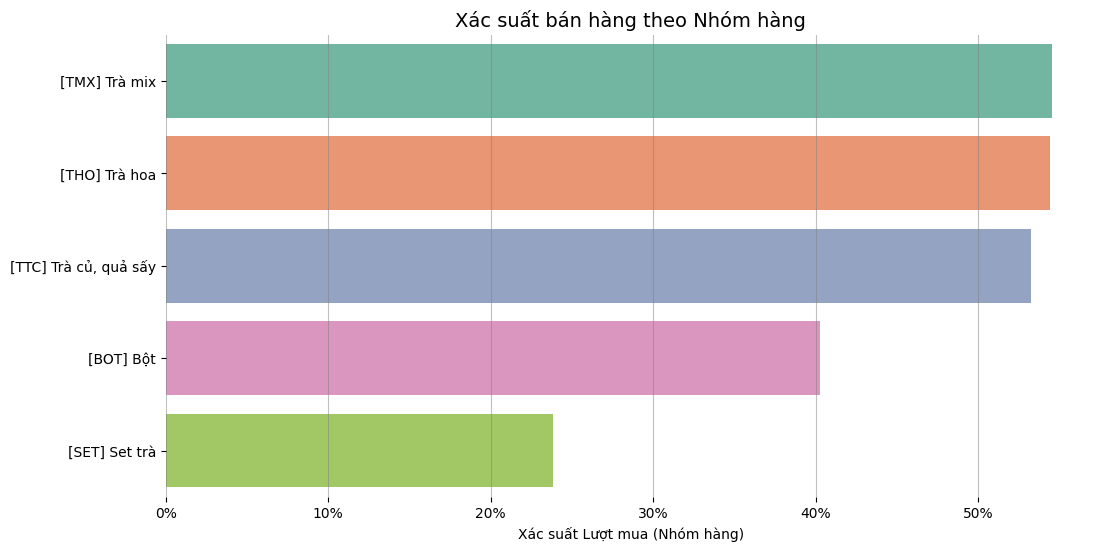

In [18]:
# --- B1: Đếm số đơn hàng duy nhất toàn bộ ---
tong_donhang = df["Mã đơn hàng"].nunique()

# --- B2: Đếm số đơn hàng duy nhất theo Nhóm hàng ---
grouped = df.groupby(["Mã nhóm hàng", "Tên nhóm hàng"])["Mã đơn hàng"].nunique().reset_index()

# --- B3: Tính xác suất ---
grouped["XacSuat"] = grouped["Mã đơn hàng"] / tong_donhang

# --- B4: Tìm nhóm dễ bán / khó bán ---
top_group = grouped.loc[grouped["XacSuat"].idxmax()]
bottom_group = grouped.loc[grouped["XacSuat"].idxmin()]

print(f"Nhóm hàng bán dễ nhất là [{top_group['Mã nhóm hàng']}] {top_group['Tên nhóm hàng']} "
      f"với xác suất bán là {top_group['XacSuat']:.2%}.")

print(f"Nhóm hàng bán khó nhất là [{bottom_group['Mã nhóm hàng']}] {bottom_group['Tên nhóm hàng']} "
      f"với xác suất bán là {bottom_group['XacSuat']:.2%}.")

# --- B5: Tạo cột hiển thị [Mã] Tên ---
grouped["Hiển thị"] = "[" + grouped["Mã nhóm hàng"].astype(str) + "] " + grouped["Tên nhóm hàng"]

# --- B6: Vẽ biểu đồ ---
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=grouped.sort_values("XacSuat", ascending=False),
    x="XacSuat",
    y="Hiển thị",
    hue="Hiển thị",     # thêm hue để tránh warning
    dodge=False,        # giữ nguyên bar
    palette="Set2",
    legend=False        # tắt legend vì đã có nhãn bên trái
)
plt.title("Xác suất bán hàng theo Nhóm hàng", fontsize=14)
plt.xlabel("Xác suất Lượt mua (Nhóm hàng)")
plt.ylabel("")

# Hiển thị % trên trục X
import matplotlib.ticker as mtick
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Xóa khung viền
for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.grid(True, linestyle="-", linewidth=0.8, color="gray", alpha=0.5)
plt.show()


### 8. Năm qua, xác xuất mua hàng (trên mỗi đơn hàng) của mỗi nhóm hàng biến thiên như thế nào theo từng tháng trong năm?. Vẽ biểu đồ trực quan và đưa ra nhận định của bản thân lý giải nguyên do của kết quả.
<i>*Note: Trả lời thành văn bản trong đó có thông tin Mã nhóm hàng, Tên nhóm hàng, Xác suất bán trên đơn hàng của tháng cao nhất, thấp nhất trong năm, xu hướng tăng giảm của xác suất bán.</i>

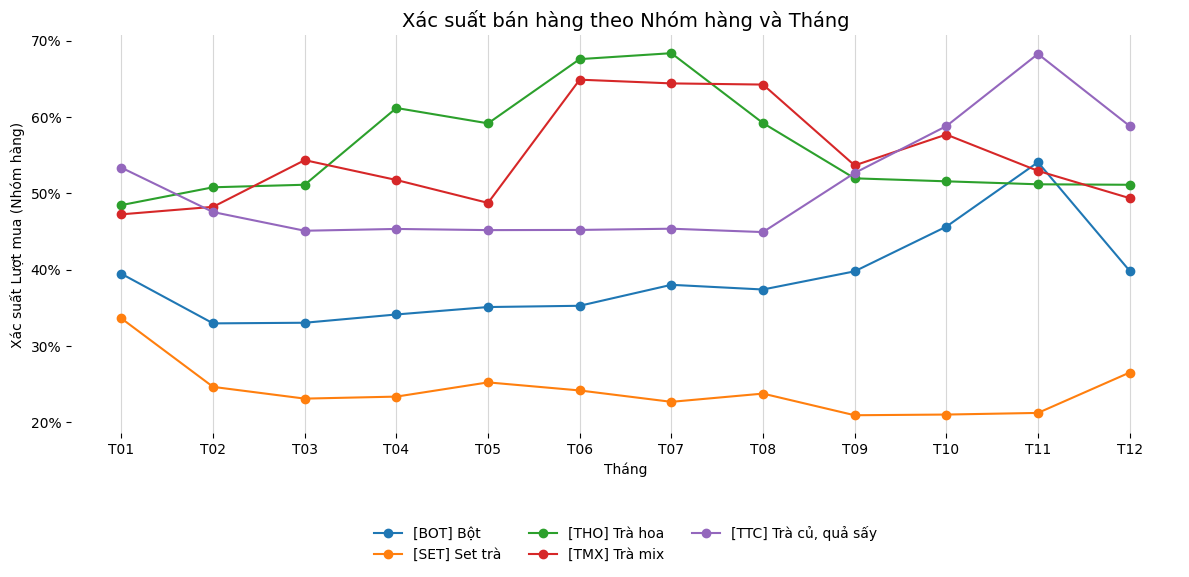

In [19]:

# --- Xử lý dữ liệu ---
df["Ngày"] = pd.to_datetime(df["Thời gian tạo đơn"], format="%Y-%m-%d %H:%M:%S")
df["Tháng"] = df["Ngày"].dt.month

# Tổng số đơn hàng duy nhất theo tháng
donhang_thang = df.groupby("Tháng")["Mã đơn hàng"].nunique().reset_index()
donhang_thang = donhang_thang.rename(columns={"Mã đơn hàng": "SoDonHang_Thang"})

# Số đơn hàng duy nhất theo Nhóm hàng + Tháng
donhang_nhom_thang = df.groupby(["Tháng", "Mã nhóm hàng", "Tên nhóm hàng"])["Mã đơn hàng"].nunique().reset_index()
donhang_nhom_thang = donhang_nhom_thang.rename(columns={"Mã đơn hàng": "SoDonHang_NhomHang_Thang"})

# Gộp dữ liệu và tính xác suất
merged = donhang_nhom_thang.merge(donhang_thang, on="Tháng", how="left")
merged["XacSuat"] = merged["SoDonHang_NhomHang_Thang"] / merged["SoDonHang_Thang"]

# Thêm cột hiển thị [Mã] Tên
merged["Hiển thị"] = "[" + merged["Mã nhóm hàng"].astype(str) + "] " + merged["Tên nhóm hàng"]

# Pivot để vẽ line chart
pivot = merged.pivot(index="Tháng", columns="Hiển thị", values="XacSuat")

# --- Vẽ biểu đồ ---
plt.figure(figsize=(12,6))

for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], marker="o", label=col)

plt.title("Xác suất bán hàng theo Nhóm hàng và Tháng", fontsize=14)
plt.xlabel("Tháng")
plt.ylabel("Xác suất Lượt mua (Nhóm hàng)")

# Format % cho trục Y
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Format trục X thành T01, T02, ...
plt.xticks(pivot.index, [f"T{m:02d}" for m in pivot.index])

# Chỉ để lại grid dọc
plt.grid(axis="x", linestyle="-", alpha=0.5)
plt.grid(axis="y", linestyle="")

# ❌ Xóa khung (spines)
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# Legend dưới biểu đồ
plt.legend(title="", bbox_to_anchor=(0.5, -0.2), loc="upper center", ncol=3, frameon=False)

plt.tight_layout()
plt.show()


### 9. Năm qua, đối với từng nhóm hàng thì mặt hàng nào thường dễ bán nhất (có xác suất bán trên mỗi đơn hàng cao nhất)? mặt hàng nào khó bán nhất (có xác suất bán trên mỗi đơn hàng thấp nhất)?. Vẽ biểu đồ trực quan (tất cả các nhóm hàng vào cùng figure) và đưa ra nhận định của bản thân lý giải nguyên do của kết quả.
<i>*Note: Trả lời thành văn bản trong đó có thông tin Mã nhóm hàng, Tên nhóm hàng, Mã mặt hàng, Tên mặt hàng, Xác suất bán trên đơn hàng.</i>


[BOT] Bột:
- Dễ bán nhất: [BOT01] Bột cần tây (100.00%)
- Khó bán nhất: [BOT01] Bột cần tây (100.00%)

[SET] Set trà:
- Dễ bán nhất: [SET03] Set 10 gói trà hoa cúc trắng (21.12%)
- Khó bán nhất: [SET07] Set 10 gói trà cam sả quế (9.37%)

[THO] Trà hoa:
- Dễ bán nhất: [THO03] Trà hoa cúc trắng (28.74%)
- Khó bán nhất: [THO04] Trà nụ hoa hồng Tây Tạng (15.45%)

[TMX] Trà mix:
- Dễ bán nhất: [TMX01] Trà dưỡng nhan (46.46%)
- Khó bán nhất: [TMX02] Trà cam sả quế (35.01%)

[TTC] Trà củ, quả sấy:
- Dễ bán nhất: [TTC01] Trà gừng (70.43%)
- Khó bán nhất: [TTC02] Cam lát (43.45%)


C:\Users\buiqu\AppData\Local\Temp\ipykernel_21020\4280233766.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\buiqu\AppData\Local\Temp\ipykernel_21020\4280233766.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\buiqu\AppData\Local\Temp\ipykernel_21020\4280233766.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\buiqu\AppData\Local\Temp\ipykernel_21020\4280233766.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `h

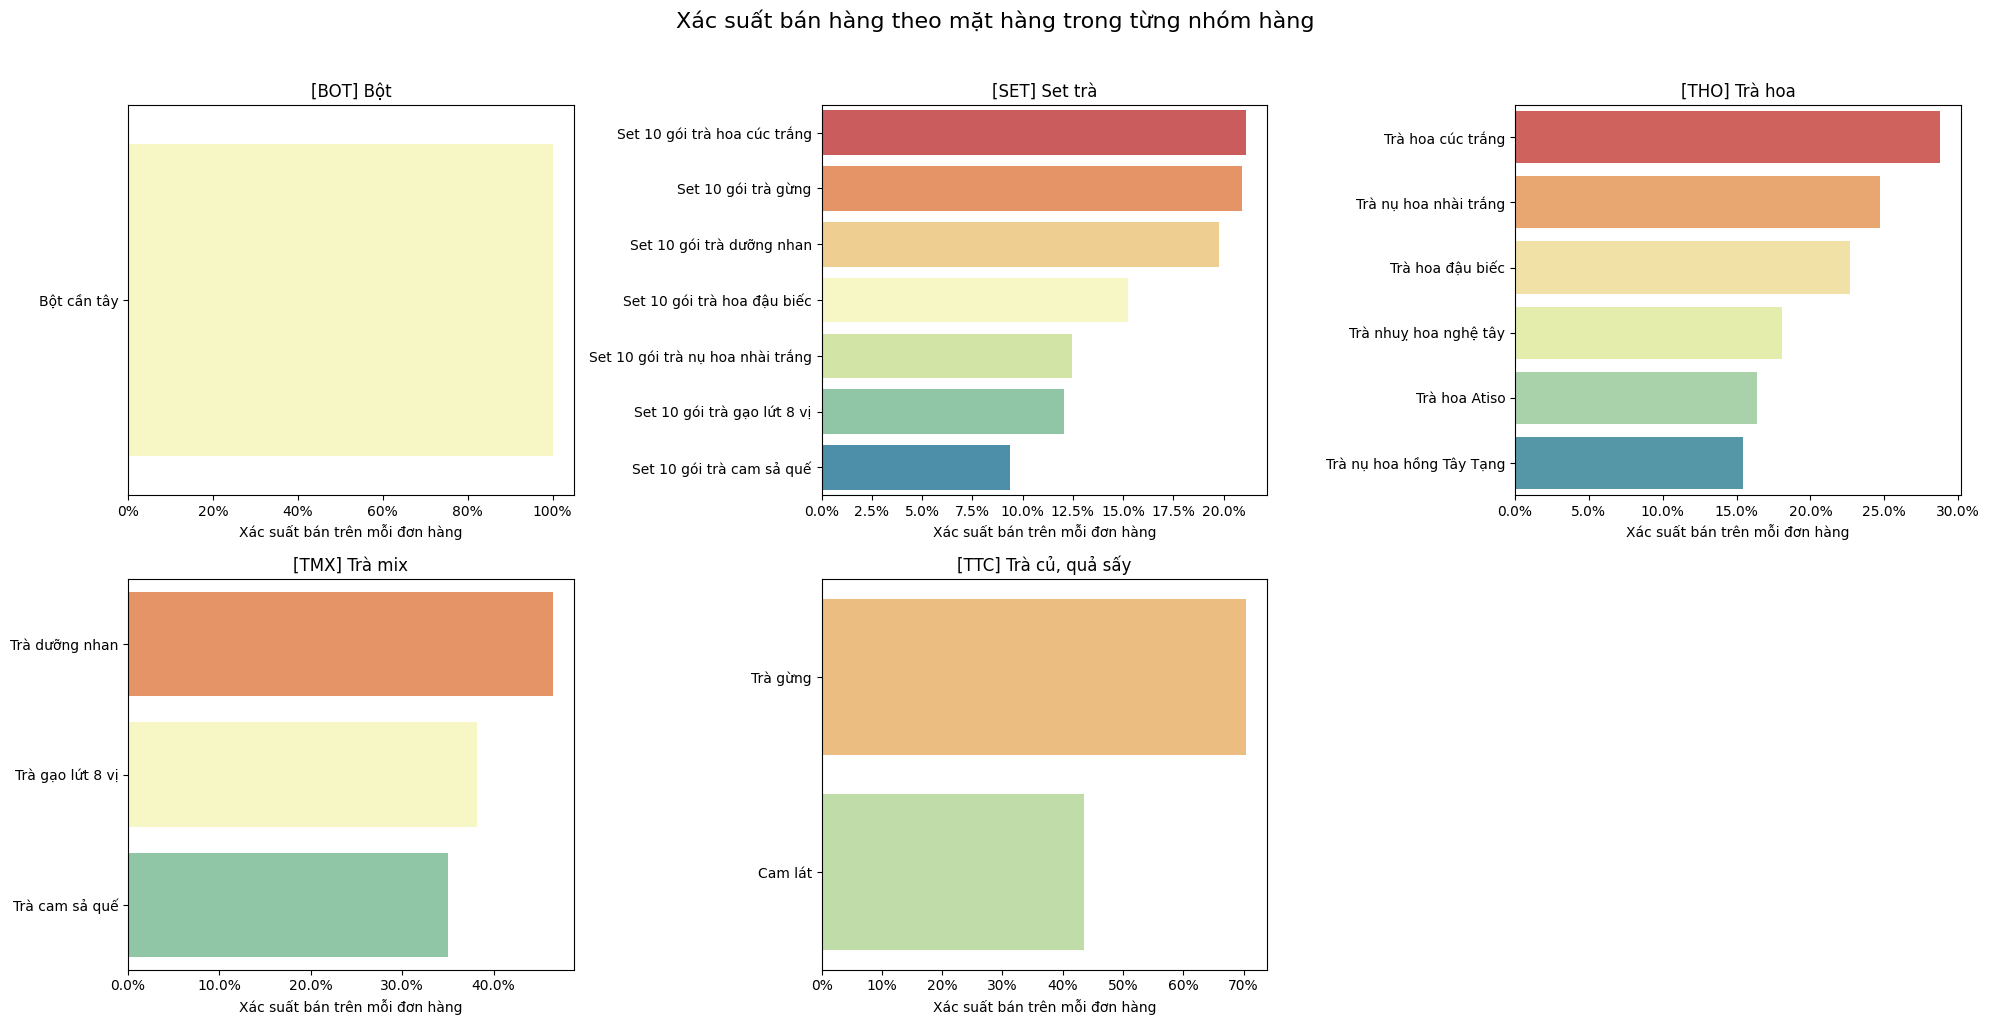

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# B1: Tính xác suất bán trên mỗi đơn hàng
# Đếm số đơn hàng có mặt hàng / tổng số đơn hàng của nhóm
df_prob = (
    df.groupby(["Mã nhóm hàng", "Tên nhóm hàng", "Mã mặt hàng", "Tên mặt hàng"])
    ["Mã đơn hàng"].nunique()
    .reset_index(name="SoDonCoMatHang")
)

tong_don_theo_nhom = (
    df.groupby(["Mã nhóm hàng", "Tên nhóm hàng"])["Mã đơn hàng"].nunique().reset_index(name="TongDon")
)

merged = df_prob.merge(tong_don_theo_nhom, on=["Mã nhóm hàng", "Tên nhóm hàng"])
merged["XacSuat"] = merged["SoDonCoMatHang"] / merged["TongDon"]

# B2: In ra mặt hàng dễ & khó bán nhất cho từng nhóm
for nhom, sub in merged.groupby(["Mã nhóm hàng", "Tên nhóm hàng"]):
    ma_nhom, ten_nhom = nhom
    best = sub.loc[sub["XacSuat"].idxmax()]
    worst = sub.loc[sub["XacSuat"].idxmin()]

    print(f"\n[{ma_nhom}] {ten_nhom}:")
    print(f"- Dễ bán nhất: [{best['Mã mặt hàng']}] {best['Tên mặt hàng']} ({best['XacSuat']:.2%})")
    print(f"- Khó bán nhất: [{worst['Mã mặt hàng']}] {worst['Tên mặt hàng']} ({worst['XacSuat']:.2%})")

# B3: Vẽ dashboard (5 bảng)
nhom_hang_list = merged["Tên nhóm hàng"].unique()
n = len(nhom_hang_list)

cols = 3
rows = -(-n // cols)  # ceil

fig, axes = plt.subplots(rows, cols, figsize=(20, 10), sharex=False, sharey=False)
axes = axes.flatten()

for ax, nhom in zip(axes, nhom_hang_list):
    sub = merged[merged["Tên nhóm hàng"] == nhom].sort_values("XacSuat", ascending=False)

    sns.barplot(
        data=sub,
        x="XacSuat",
        y="Tên mặt hàng",
        ax=ax,
        palette="Spectral",
    )
    ax.set_title(f"[{sub['Mã nhóm hàng'].iloc[0]}] {nhom}")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_xlabel("Xác suất bán trên mỗi đơn hàng")
    ax.set_ylabel("")

# Ẩn subplot thừa
for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle("Xác suất bán hàng theo mặt hàng trong từng nhóm hàng", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


### 10. Năm qua, xác xuất mua hàng (trên mỗi đơn hàng) của mỗi mặt hàng trong mỗi nhóm hàng biến thiên như thế nào theo từng tháng trong năm?. Vẽ biểu đồ trực quan (tất cả các nhóm hàng vào cùng figure) và đưa ra nhận định của bản thân lý giải nguyên do của kết quả.
<i>*Note: Trả lời thành văn bản trong đó có thông tin Mã nhóm hàng, Tên nhóm hàng, Mã mặt hàng, Tên mặt hàng, Xác suất bán trên đơn hàng của tháng cao nhất, thấp nhất trong năm, xu hướng tăng giảm của xác suất bán.</i>

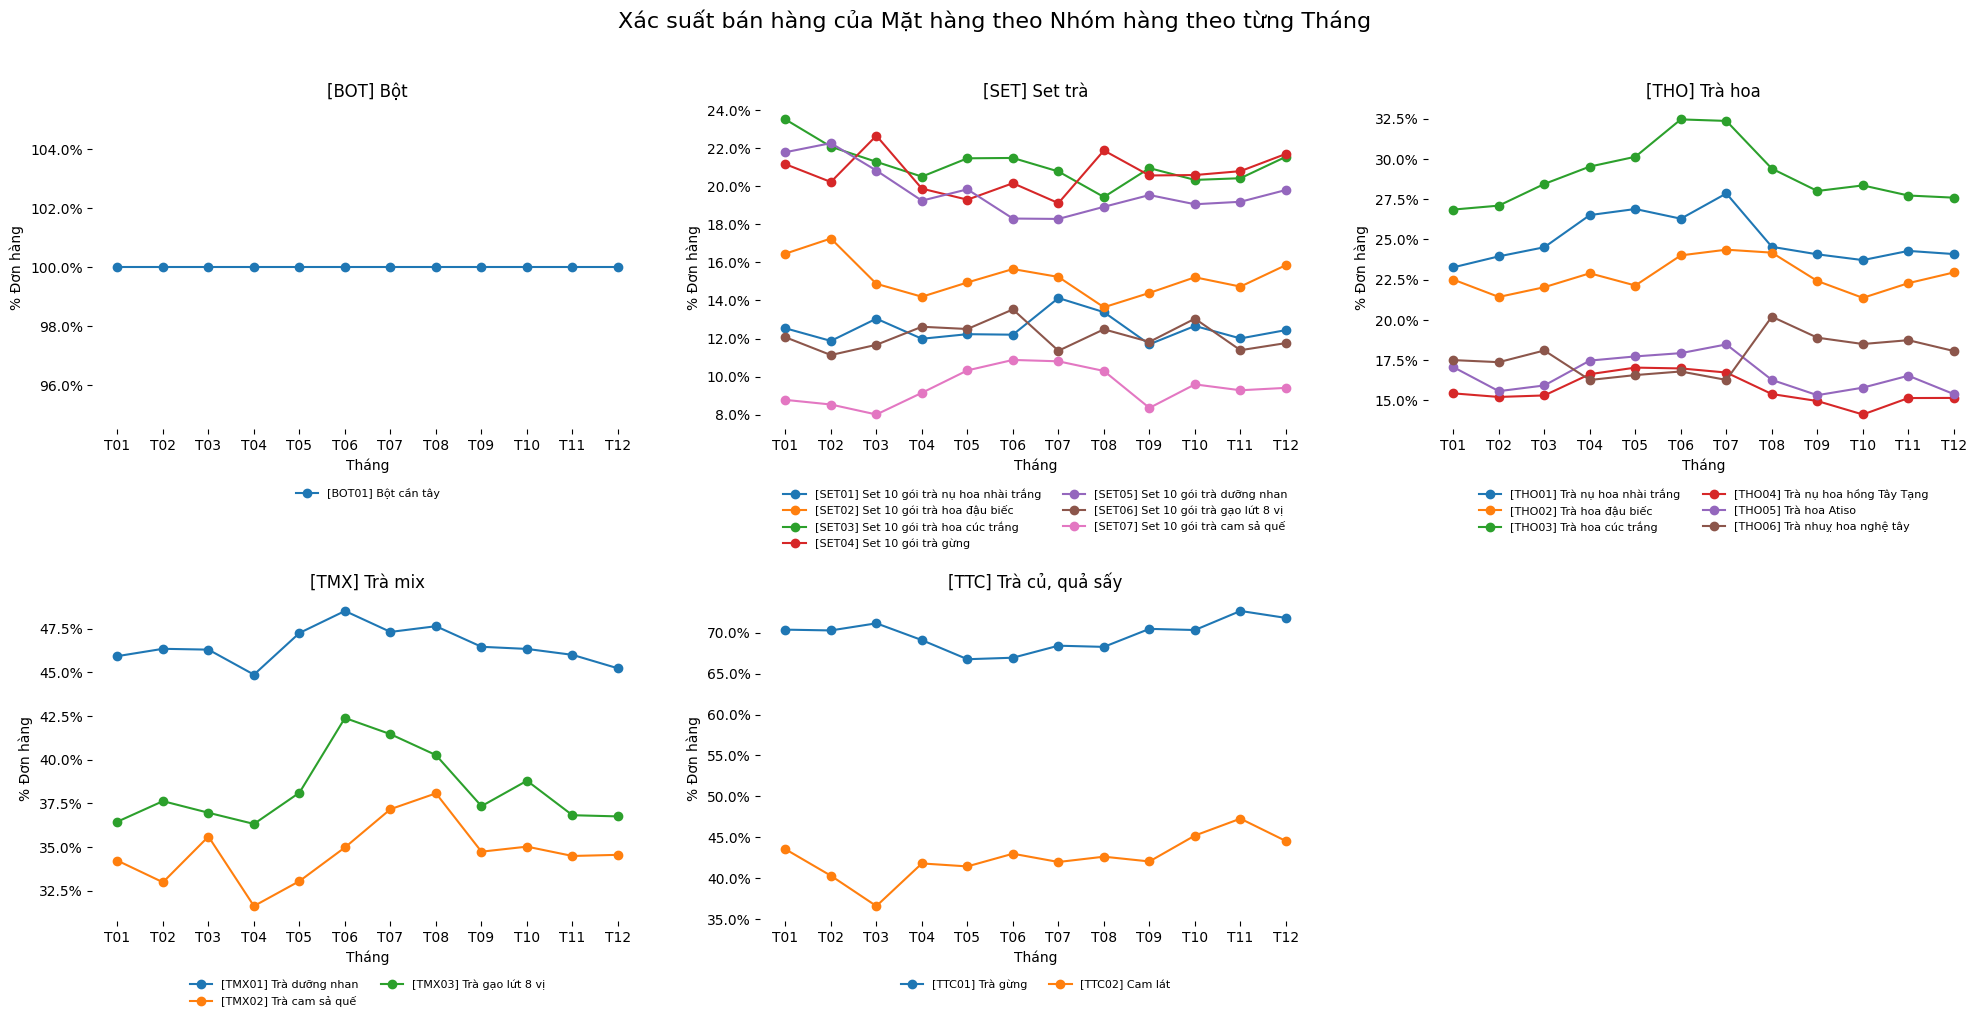

In [28]:


# --- Xử lý dữ liệu ---
df["Ngày"] = pd.to_datetime(df["Thời gian tạo đơn"], format="%Y-%m-%d %H:%M:%S")
df["Tháng"] = df["Ngày"].dt.month

# Số đơn hàng duy nhất theo Nhóm hàng + Tháng
donhang_nhom_thang = (
    df.groupby(["Tháng", "Mã nhóm hàng", "Tên nhóm hàng"])["Mã đơn hàng"]
    .nunique()
    .reset_index()
    .rename(columns={"Mã đơn hàng": "SoDonHang_NhomHang_Thang"})
)

# Số đơn hàng duy nhất theo Mặt hàng trong Nhóm hàng + Tháng
donhang_mathang_thang = (
    df.groupby(["Tháng", "Mã nhóm hàng", "Tên nhóm hàng", "Mã mặt hàng", "Tên mặt hàng"])["Mã đơn hàng"]
    .nunique()
    .reset_index()
    .rename(columns={"Mã đơn hàng": "SoDonHang_MatHang_Thang"})
)

# Merge và tính % theo nhóm
merged = donhang_mathang_thang.merge(
    donhang_nhom_thang,
    on=["Tháng", "Mã nhóm hàng", "Tên nhóm hàng"],
    how="left"
)
merged["TyLe"] = merged["SoDonHang_MatHang_Thang"] / merged["SoDonHang_NhomHang_Thang"]

# Thêm hiển thị [Mã] Tên mặt hàng
merged["Hiển thị"] = "[" + merged["Mã mặt hàng"].astype(str) + "] " + merged["Tên mặt hàng"]

# --- Vẽ subplot ---
nhom_hang_list = merged["Tên nhóm hàng"].unique()
n = len(nhom_hang_list)

cols = 3
rows = math.ceil(n / cols)
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(20, 10), sharey=False)
axes = axes.flatten()

for ax, nhom in zip(axes, nhom_hang_list):
    sub = merged[merged["Tên nhóm hàng"] == nhom]

    for hienthi, sub2 in sub.groupby("Hiển thị"):
        ax.plot(sub2["Tháng"], sub2["TyLe"], marker="o", label=hienthi)

    ma_nhom = sub["Mã nhóm hàng"].iloc[0]
    ax.set_title(f"[{ma_nhom}] {nhom}", fontsize=12)
    ax.set_xlabel("Tháng")
    ax.set_ylabel("% Đơn hàng")

    # Format Y riêng cho từng subplot
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    # Hiển thị đủ tháng T01 - T12
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels([f"T{m:02d}" for m in range(1, 13)])

    # Xóa khung
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Legend dưới mỗi chart
    ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

# Ẩn subplot thừa
for ax in axes[len(nhom_hang_list):]:
    ax.set_visible(False)

plt.suptitle("Xác suất bán hàng của Mặt hàng theo Nhóm hàng theo từng Tháng", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


### 11. Năm qua, phân phối mức độ mua lặp lại của khách hàng như thế nào?. Vẽ biểu đồ trực quan (histogram) và đưa ra nhận định của bản thân lý giải nguyên do của kết quả.
<i>*Note: Trả lời thành văn bản trong đó có thông tin Số lần mua lặp lại, mức độ phân bổ của các mức mua lặp lại của khách hàng.</i>

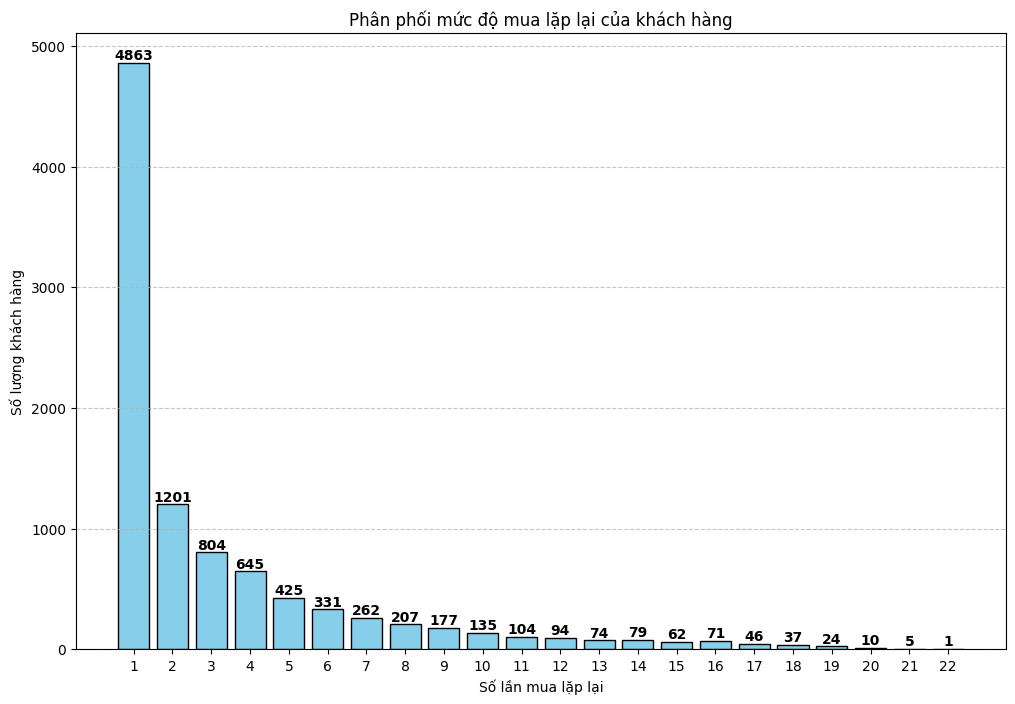

In [29]:
# Tính số lần mua lặp lại của mỗi khách hàng
repeat_counts = df.groupby('Mã khách hàng')['Mã đơn hàng'].nunique().value_counts().sort_index()

# Vẽ bar chart
plt.figure(figsize=(12, 8))
bars = plt.bar(
    repeat_counts.index, 
    repeat_counts.values, 
    color="skyblue", edgecolor="black"  # màu skyblue + viền đen
)

# Thêm nhãn số lượng trên mỗi cột
for bar, value in zip(bars, repeat_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        str(value),
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.xlabel('Số lần mua lặp lại')
plt.ylabel('Số lượng khách hàng')
plt.title('Phân phối mức độ mua lặp lại của khách hàng')
plt.xticks(repeat_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### 12. Năm qua, phân phối số tiền của khách hàng đã chi trả cho doanh nghiệp như thế nào?. Vẽ biểu đồ trực quan (histogram) và đưa ra nhận định của bản thân lý giải nguyên do của kết quả.
<i>*Note: Trả lời thành văn bản trong đó có thông tin Số tiền khách hàng đã chi trả, mức độ phân bổ của các mức mua lặp lại của khách hàng.</i>

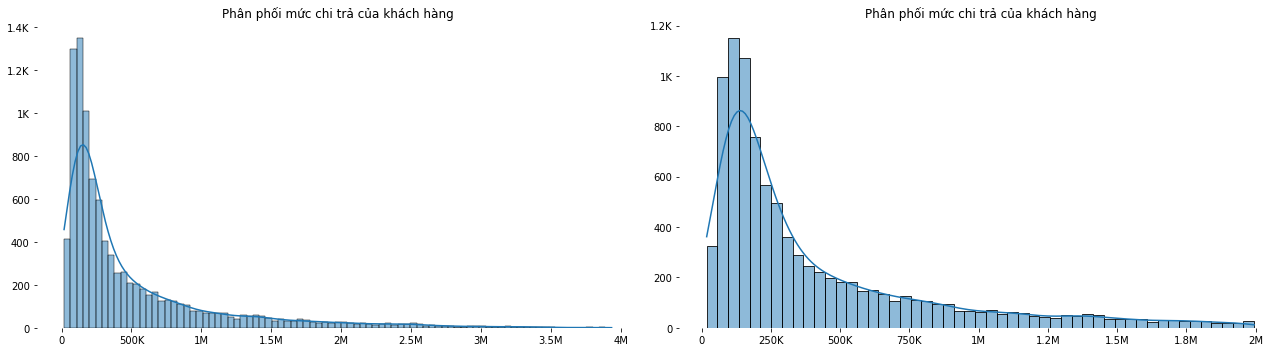

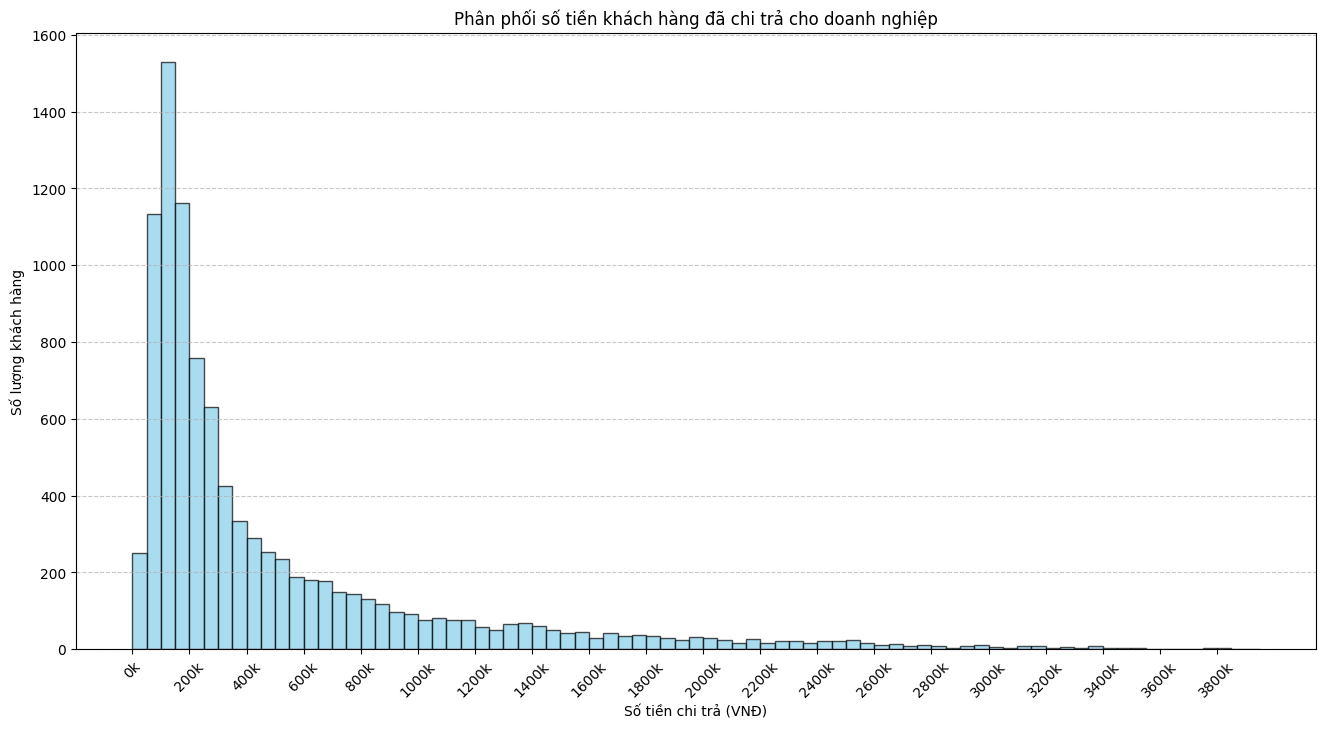

In [27]:
import numpy as np

# Tính tổng số tiền chi trả của mỗi khách hàng
customer_spending = df.groupby('Mã khách hàng')['Thành tiền'].sum()

# Chia bin mỗi 50k
bin_size = 50_000
bins = np.arange(0, customer_spending.max() + bin_size, bin_size)

# Vẽ histogram
plt.figure(figsize=(16, 8))  # phóng to biểu đồ
plt.hist(customer_spending, bins=bins, color='skyblue', edgecolor='black', alpha=0.7)

# Chỉnh nhãn trục X thành đơn vị "k"
xticks = np.arange(0, customer_spending.max() + bin_size, 200_000)  # nhảy 200k 1 tick để dễ nhìn
xtick_labels = [f"{int(x/1000)}k" for x in xticks]
plt.xticks(xticks, xtick_labels, rotation=45)

# Thêm nhãn và tiêu đề
plt.xlabel('Số tiền chi trả (VNĐ)')
plt.ylabel('Số lượng khách hàng')
plt.title('Phân phối số tiền khách hàng đã chi trả cho doanh nghiệp')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

